# 01 — Robust data loading, QC, doublet detection and normalization

**Purpose:** Revised end-to-end preprocessing for the Drosophila brain scRNA-seq project.

This version directly addresses the reviewer concerns about:
- `sc.read_10x_mtx` loading failures;
- transparent per-sample QC counts;
- doublet detection;
- preservation of raw counts for sample-level pseudobulk DE;
- preservation of the full log-normalized gene matrix for DE;
- keeping HVG selection separate from DE;
- reproducible output files and figures.

**Expected input:** eight 10x samples under `../data/`, e.g.
`Female_Cocaine_1`, `Female_Cocaine_2`, `Female_Sucrose_1`, `Female_Sucrose_2`,
`Male_Cocaine_1`, `Male_Cocaine_2`, `Male_Sucrose_1`, `Male_Sucrose_2`.

The loader is intentionally not dependent on `sc.read_10x_mtx`; it reads the Matrix Market, barcode and feature files directly so minor 10x naming differences do not cause a `KeyError`.

In [1]:
from pathlib import Path
import gzip
import gc
import re
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)
print("Scanpy:", sc.__version__)
print("Data directory:", DATA_DIR.resolve())

Scanpy: 1.11.5
Data directory: /home/tanvir-ahmed/scproject2-drosophila-brain/data


/tmp/ipykernel_8707/511100383.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 1. Locate and validate the eight samples

The code below accepts `.gz` or uncompressed 10x files and also tolerates one extra directory level. It explicitly checks that every sample contains a matrix, barcodes and features file before attempting to load it.

In [2]:
EXPECTED_SAMPLES = [
    "Female_Cocaine_1", "Female_Cocaine_2",
    "Female_Sucrose_1", "Female_Sucrose_2",
    "Male_Cocaine_1", "Male_Cocaine_2",
    "Male_Sucrose_1", "Male_Sucrose_2",
]

def find_file(folder, stems):
    for stem in stems:
        for suffix in ("", ".gz"):
            p = folder / (stem + suffix)
            if p.exists():
                return p
    return None

def find_10x_files(sample_dir):
    candidates = [sample_dir] + [p for p in sample_dir.rglob("*") if p.is_dir()]
    for folder in candidates:
        matrix = find_file(folder, ["matrix.mtx", "matrix.mtx.gz".replace(".gz","")])
        if matrix is None:
            # find_file already checks .gz; this branch simply keeps the code explicit
            matrix = next((p for p in folder.iterdir() if p.name in {"matrix.mtx","matrix.mtx.gz"}), None) if folder.exists() else None
        barcodes = next((p for p in folder.iterdir() if p.name in {"barcodes.tsv","barcodes.tsv.gz"}), None) if folder.exists() else None
        features = next((p for p in folder.iterdir() if p.name in {"features.tsv","features.tsv.gz","genes.tsv","genes.tsv.gz"}), None) if folder.exists() else None
        if matrix and barcodes and features:
            return matrix, barcodes, features, folder
    raise FileNotFoundError(
        f"Could not find a complete 10x matrix/barcodes/features set inside {sample_dir}"
    )

sample_dirs = {}
for sample in EXPECTED_SAMPLES:
    p = DATA_DIR / sample
    if not p.exists():
        raise FileNotFoundError(f"Missing expected sample folder: {p}")
    sample_dirs[sample] = p

print("Found sample folders:")
for s, p in sample_dirs.items():
    matrix, barcodes, features, folder = find_10x_files(p)
    print(f"  {s}: {folder} | {matrix.name}, {barcodes.name}, {features.name}")

Found sample folders:
  Female_Cocaine_1: ../data/Female_Cocaine_1 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Female_Cocaine_2: ../data/Female_Cocaine_2 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Female_Sucrose_1: ../data/Female_Sucrose_1 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Female_Sucrose_2: ../data/Female_Sucrose_2 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Male_Cocaine_1: ../data/Male_Cocaine_1 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Male_Cocaine_2: ../data/Male_Cocaine_2 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Male_Sucrose_1: ../data/Male_Sucrose_1 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
  Male_Sucrose_2: ../data/Male_Sucrose_2 | matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz


## 2. Robust 10x reader

Some versions of Scanpy are strict about the exact 10x feature-file format. This reader uses `scipy.io.mmread` and standard text parsing instead, avoiding the `KeyError` reported by the reviewer.

In [3]:
def open_text(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "rt")

def read_tsv(path):
    with open_text(path) as f:
        return [line.rstrip("\n").split("\t") for line in f if line.strip()]

def read_10x_manual(sample_dir, sample_name):
    matrix_path, barcode_path, feature_path, used_dir = find_10x_files(sample_dir)

    X = mmread(str(matrix_path)).tocsr()
    barcodes = [row[0] for row in read_tsv(barcode_path)]

    feature_rows = read_tsv(feature_path)
    if not feature_rows:
        raise ValueError(f"No feature rows found in {feature_path}")

    # 10x v3: gene_id, gene_symbol, feature_type
    # Older 10x: gene_id, gene_symbol
    gene_ids = [r[0] for r in feature_rows]
    gene_symbols = [r[1] if len(r) >= 2 and r[1] else r[0] for r in feature_rows]
    feature_types = [r[2] if len(r) >= 3 else "Gene Expression" for r in feature_rows]

    if X.shape[0] != len(gene_symbols) or X.shape[1] != len(barcodes):
        raise ValueError(
            f"{sample_name}: matrix shape {X.shape} does not match "
            f"{len(gene_symbols)} genes x {len(barcodes)} barcodes"
        )

    # Keep Gene Expression features when feature types are present.
    gene_mask = np.array([ft == "Gene Expression" for ft in feature_types])
    if gene_mask.any():
        X = X[gene_mask, :]
        gene_ids = list(np.array(gene_ids)[gene_mask])
        gene_symbols = list(np.array(gene_symbols)[gene_mask])

    # Duplicated symbols are made unique while retaining the original IDs.
    var_names = pd.Index(gene_symbols.astype if False else gene_symbols).astype(str)
    var_names = pd.Index(var_names).where(var_names != "", pd.Index(gene_ids).astype(str))
    var_names = pd.Index(var_names).to_numpy()
    var_names = pd.Index(var_names).to_series().astype(str)
    var_names = pd.Index(pd.io.parsers.ParserBase({"names": var_names})._maybe_dedup_names(list(var_names))) if False else pd.Index(var_names)
    # Simple deterministic uniqueness without relying on private pandas APIs.
    seen = {}
    unique_names = []
    for name in var_names:
        if name not in seen:
            seen[name] = 0
            unique_names.append(name)
        else:
            seen[name] += 1
            unique_names.append(f"{name}-{seen[name]}")
    var_names = pd.Index(unique_names)

    a = ad.AnnData(X=X.T.tocsr())
    a.var_names = var_names
    a.obs_names = pd.Index(barcodes).astype(str)
    a.var["gene_id"] = gene_ids
    a.var["feature_type"] = "Gene Expression"
    a.obs["sample"] = sample_name

    parts = sample_name.split("_")
    a.obs["sex"] = parts[0]
    a.obs["treatment"] = parts[1]
    a.obs["replicate"] = parts[2]
    a.obs["condition"] = f"{parts[0]}_{parts[1]}"
    return a

# Test all eight loaders before doing any downstream work.
test_shapes = {}
for sample, path in sample_dirs.items():
    a = read_10x_manual(path, sample)
    test_shapes[sample] = a.shape
    print(f"{sample}: {a.n_obs:,} cells x {a.n_vars:,} genes")
    del a
    gc.collect()

Female_Cocaine_1: 13,072 cells x 17,481 genes
Female_Cocaine_2: 9,367 cells x 17,481 genes
Female_Sucrose_1: 9,072 cells x 17,481 genes
Female_Sucrose_2: 11,693 cells x 17,481 genes
Male_Cocaine_1: 10,437 cells x 17,481 genes
Male_Cocaine_2: 11,124 cells x 17,481 genes
Male_Sucrose_1: 13,193 cells x 17,481 genes
Male_Sucrose_2: 11,033 cells x 17,481 genes


## 3. Per-sample filtering and doublet detection

We first retain cells with at least 200 detected genes and genes detected in at least 3 cells. Doublet detection is then performed **per sample on raw counts**, which is the recommended input form for Scanpy's Scrublet wrapper. Predicted doublets are excluded from the final analysis.

If Scrublet fails for a particular sample because of memory, the notebook stops rather than silently pretending that doublet detection was completed.

In [4]:
# ================================================================
# PER-SAMPLE QC: BASIC FILTERING + MITOCHONDRIAL QC + SCRUBLET
# ================================================================

def identify_gene_categories(adata):
    """
    Identify mitochondrial and ribosomal genes from the feature
    naming convention used in GSE152495.

    Example feature names:
        Dmel_CG17131 tyn Gene Expression
        Dmel_CR34064 mt:tRNA:Trp-TCA Gene Expression
    """

    features = adata.var_names.astype(str)

    # ------------------------------------------------------------
    # Extract the gene symbol from the 10x feature annotation.
    #
    # Example:
    # Dmel_CG17131 tyn Gene Expression
    #                     ↓
    #                    tyn
    #
    # Dmel_CR34064 mt:tRNA:Trp-TCA Gene Expression
    #                     ↓
    #              mt:tRNA:Trp-TCA
    # ------------------------------------------------------------

    gene_symbols = (
        features
        .str.replace(r"^Dmel_\S+\s+", "", regex=True)
        .str.replace(r"\s+Gene Expression$", "", regex=True)
    )

    adata.var["gene_symbol"] = gene_symbols

    # ------------------------------------------------------------
    # Mitochondrial genes
    #
    # In this dataset mitochondrial transcripts are annotated as
    # mt:tRNA, mt:lrRNA, mt:srRNA, etc.
    #
    # IMPORTANT:
    # Do not simply search for "mt" because genes such as Hmt-1
    # are not mitochondrial transcripts.
    # ------------------------------------------------------------

    adata.var["mt"] = (
        gene_symbols
        .str.lower()
        .str.startswith("mt:")
    )

    # ------------------------------------------------------------
    # Ribosomal genes
    #
    # Drosophila ribosomal genes commonly begin with RpS or RpL.
    # ------------------------------------------------------------

    adata.var["ribo"] = gene_symbols.str.match(
        r"^(RpS|RpL)",
        case=False,
        na=False
    )

    return adata


# ================================================================
# PROCESS ALL SAMPLES
# ================================================================

sample_adatas = {}
qc_rows = []

for sample, path in sample_dirs.items():

    print("\n" + "=" * 70)
    print(f"Processing: {sample}")
    print("=" * 70)

    # ------------------------------------------------------------
    # Load RAW 10x counts
    # ------------------------------------------------------------

    a = read_10x_manual(path, sample)

    before = a.n_obs

    print(f"Input cells: {before:,}")
    print(f"Input genes: {a.n_vars:,}")

    # ------------------------------------------------------------
    # Basic cell and gene filtering
    # ------------------------------------------------------------

    sc.pp.filter_cells(a, min_genes=200)
    sc.pp.filter_genes(a, min_cells=3)

    after_basic = a.n_obs

    print(f"After basic QC: {after_basic:,}")

    # ------------------------------------------------------------
    # Identify mitochondrial and ribosomal genes
    # ------------------------------------------------------------

    a = identify_gene_categories(a)

    n_mt_genes = int(a.var["mt"].sum())
    n_ribo_genes = int(a.var["ribo"].sum())

    print(f"Mitochondrial genes detected: {n_mt_genes}")
    print(f"Ribosomal genes detected: {n_ribo_genes}")

    # ------------------------------------------------------------
    # Calculate QC metrics
    # ------------------------------------------------------------

    sc.pp.calculate_qc_metrics(
        a,
        qc_vars=["mt", "ribo"],
        percent_top=None,
        log1p=False,
        inplace=True,
    )

    # ------------------------------------------------------------
    # Check mitochondrial percentage
    # ------------------------------------------------------------

    print(
        "Median mitochondrial percentage: "
        f"{a.obs['pct_counts_mt'].median():.3f}%"
    )

    print(
        "Maximum mitochondrial percentage: "
        f"{a.obs['pct_counts_mt'].max():.3f}%"
    )

    # ------------------------------------------------------------
    # Mitochondrial QC
    #
    # Remove cells with >10% mitochondrial counts.
    # ------------------------------------------------------------

    a = a[a.obs["pct_counts_mt"] < 10.0].copy()

    after_mito = a.n_obs

    print(f"After mitochondrial QC: {after_mito:,}")

    # ------------------------------------------------------------
    # SCRUBLET DOUBLEt DETECTION
    #
    # Scanpy 1.11.5 does not accept rng= or random_seed=
    # in sc.pp.scrublet(), so neither is supplied here.
    # ------------------------------------------------------------

    sc.pp.scrublet(
        a,
        expected_doublet_rate=0.05,
        n_prin_comps=30,
        sim_doublet_ratio=2.0,
        verbose=False,
    )

    # ------------------------------------------------------------
    # Count predicted doublets
    # ------------------------------------------------------------

    n_doublets = int(
        a.obs["predicted_doublet"].sum()
    )

    print(f"Predicted doublets: {n_doublets:,}")

    # ------------------------------------------------------------
    # Remove predicted doublets
    # ------------------------------------------------------------

    a = a[~a.obs["predicted_doublet"]].copy()

    after_doublet = a.n_obs

    print(f"Final cells: {after_doublet:,}")

    # ------------------------------------------------------------
    # Save QC information
    # ------------------------------------------------------------

    qc_rows.append({
        "sample": sample,

        "sex": a.obs["sex"].iloc[0],
        "treatment": a.obs["treatment"].iloc[0],
        "replicate": a.obs["replicate"].iloc[0],

        "cells_input": before,
        "cells_after_basic_qc": after_basic,
        "cells_after_mito_qc": after_mito,

        "mitochondrial_genes_detected": n_mt_genes,
        "ribosomal_genes_detected": n_ribo_genes,

        "predicted_doublets": n_doublets,
        "cells_after_doublet_qc": after_doublet,

        "pct_retained_final": (
            100 * after_doublet / before
        ),
    })

    # ------------------------------------------------------------
    # Store cleaned sample
    # ------------------------------------------------------------

    sample_adatas[sample] = a

    print(
        f"\nSummary: "
        f"{before:,} → "
        f"{after_basic:,} basic QC → "
        f"{after_mito:,} mito QC → "
        f"{n_doublets:,} doublets → "
        f"{after_doublet:,} final"
    )

    gc.collect()


# ================================================================
# CREATE QC SUMMARY TABLE
# ================================================================

qc_summary = (
    pd.DataFrame(qc_rows)
    .sort_values("sample")
    .reset_index(drop=True)
)

# Save table
qc_summary.to_csv(
    TABLE_DIR / "qc_cell_counts_by_sample.csv",
    index=False,
)

# Display
qc_summary


Processing: Female_Cocaine_1
Input cells: 13,072
Input genes: 17,481
filtered out 7024 genes that are detected in less than 3 cells
After basic QC: 13,072
Mitochondrial genes detected: 7
Ribosomal genes detected: 86
Median mitochondrial percentage: 0.157%
Maximum mitochondrial percentage: 5.767%
After mitochondrial QC: 13,072
Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
    Scrublet finished (0:02:15)
Predicted doublets: 0
Final cells: 13,072

Summary: 13,072 → 13,072 basic QC → 13,072 mito QC → 0 doublets → 13,072 final

Processing: Female_Cocaine_2
Input cells: 9,367
Input genes: 17,481
filtered out 5 cells that have less than 200 genes expressed
filtered out 6630 genes that are detected in less than 3 cells
After basic QC: 9,362
Mitoc

,sample,sex,treatment,replicate,cells_input,cells_after_basic_qc,cells_after_mito_qc,mitochondrial_genes_detected,ribosomal_genes_detected,predicted_doublets,cells_after_doublet_qc,pct_retained_final
0,Female_Cocaine_1,Female,Cocaine,1,13072,13072,13072,7,86,0,13072,100.000000
1,Female_Cocaine_2,Female,Cocaine,2,9367,9362,9315,7,86,1,9314,99.434184
2,Female_Sucrose_1,Female,Sucrose,1,9072,9068,9068,4,86,0,9068,99.955908
3,Female_Sucrose_2,Female,Sucrose,2,11693,11693,11693,5,86,0,11693,100.000000
4,Male_Cocaine_1,Male,Cocaine,1,10437,10436,10433,7,86,0,10433,99.961675
5,Male_Cocaine_2,Male,Cocaine,2,11124,11124,11124,9,87,0,11124,100.000000
6,Male_Sucrose_1,Male,Sucrose,1,13193,13192,13191,9,87,0,13191,99.984840
7,Male_Sucrose_2,Male,Sucrose,2,11033,11033,11027,8,86,0,11027,99.945618


## 4. Merge samples and preserve the count matrix

The count matrix is saved in `adata.layers["counts"]` **before normalization**. This is essential for the later sample-level pseudobulk analysis.

We keep the full gene set after QC. HVGs are selected later only for PCA/clustering; they are **not used to restrict DE**.

In [5]:
adata = ad.concat(
    sample_adatas,
    label="sample_batch",
    index_unique="-",
    join="outer",
    fill_value=0,
)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.notna()].copy()

# Preserve raw counts for pseudobulk.
adata.layers["counts"] = adata.X.copy()

# Full-gene log-normalized matrix. This remains separate from scaled data.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Record QC summary after all filtering.
print(f"Final cells: {adata.n_obs:,}")
print(f"Final genes: {adata.n_vars:,}")
print(adata.obs[["sample","sex","treatment","replicate"]].drop_duplicates().sort_values(["sex","treatment","replicate"]))

normalizing counts per cell
    finished (0:00:13)
Final cells: 88,922
Final genes: 11,946
                                               sample     sex treatment  \
AAACCCAAGACAAGCC-1-Female_Cocaine_1  Female_Cocaine_1  Female   Cocaine   
AAACCCAAGAAGCCTG-1-Female_Cocaine_2  Female_Cocaine_2  Female   Cocaine   
AAACCCAAGATTGACA-1-Female_Sucrose_1  Female_Sucrose_1  Female   Sucrose   
AAACCCAAGCCACTCG-1-Female_Sucrose_2  Female_Sucrose_2  Female   Sucrose   
AAACCCAAGAATCTAG-1-Male_Cocaine_1      Male_Cocaine_1    Male   Cocaine   
AAACCCAAGAAGGGAT-1-Male_Cocaine_2      Male_Cocaine_2    Male   Cocaine   
AAACCCAAGGTGCGAT-1-Male_Sucrose_1      Male_Sucrose_1    Male   Sucrose   
AAACCCAAGAACTCCT-1-Male_Sucrose_2      Male_Sucrose_2    Male   Sucrose   

                                    replicate  
AAACCCAAGACAAGCC-1-Female_Cocaine_1         1  
AAACCCAAGAAGCCTG-1-Female_Cocaine_2         2  
AAACCCAAGATTGACA-1-Female_Sucrose_1         1  
AAACCCAAGCCACTCG-1-Female_Sucrose_2      

## 5. HVGs for clustering only

HVG selection is explicitly separated from DE. The full log-normalized matrix remains in `adata.X`; only the boolean `highly_variable` flag is used downstream for PCA/clustering.

extracting highly variable genes
    finished (0:00:13)
Number of HVGs: 2000


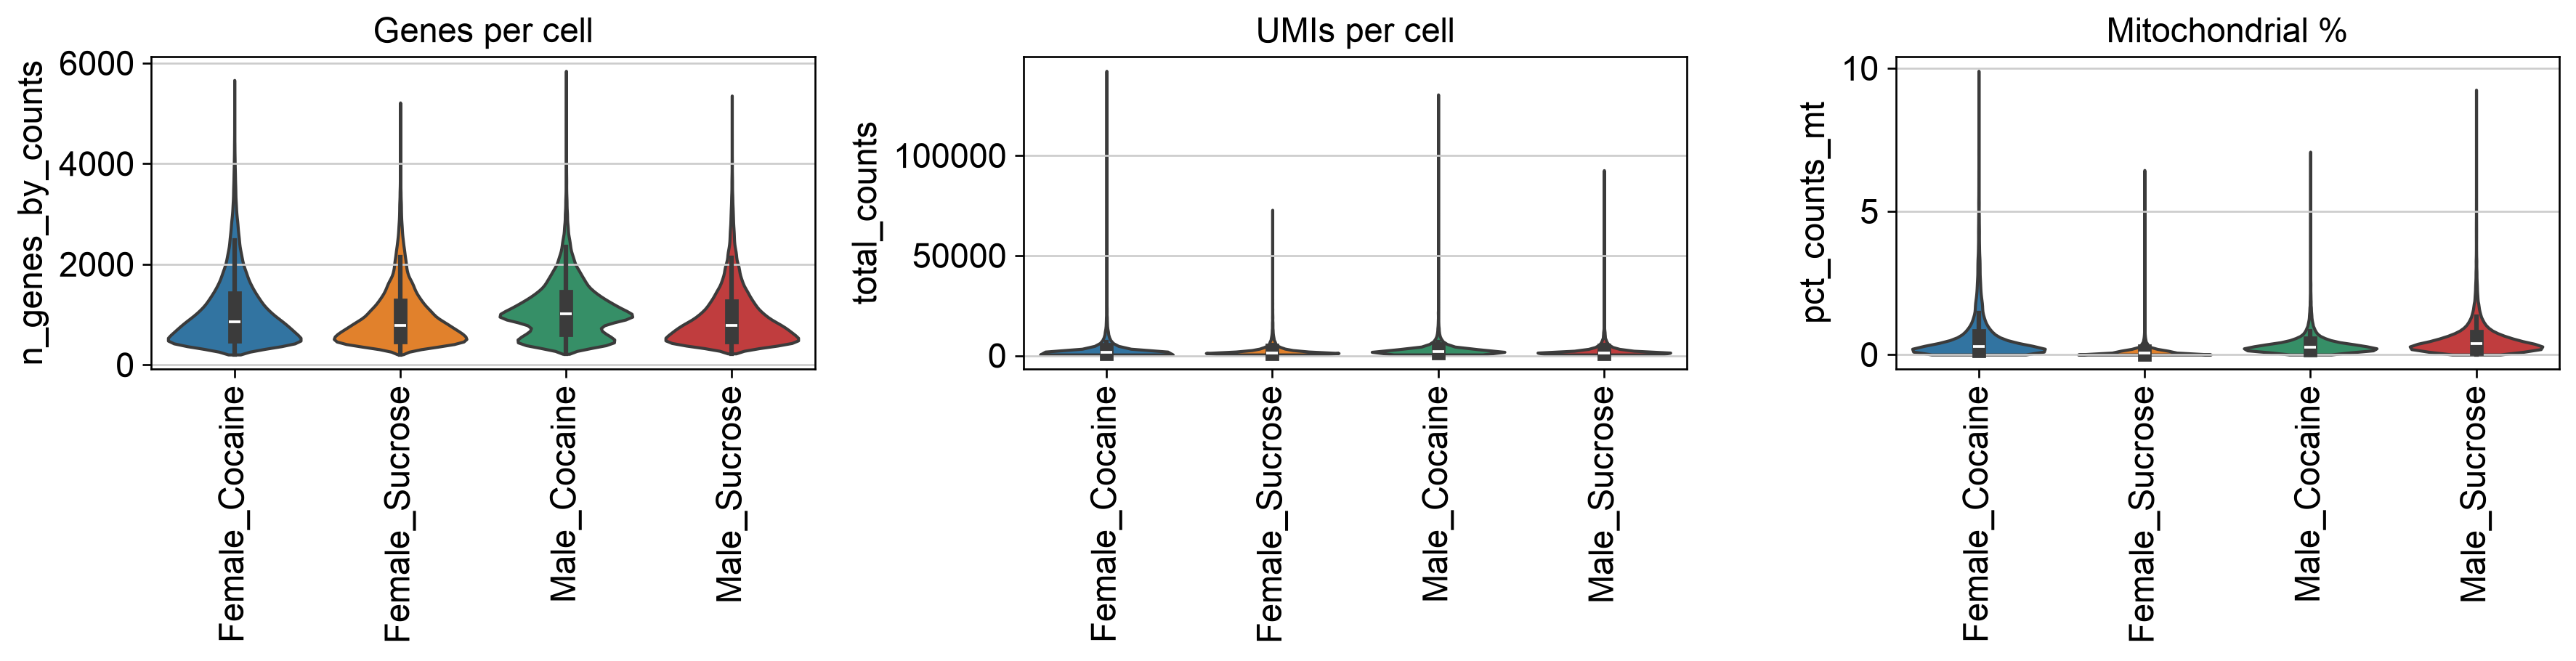

Saved:
  ../results/adata_qc_normalized.h5ad
  ../results/tables/qc_cell_counts_by_sample.csv
  ../results/figures/fig1_qc_summary.png


In [6]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    batch_key="sample",
    flavor="seurat",
)
print("Number of HVGs:", int(adata.var["highly_variable"].sum()))

# Save the full-gene log-normalized object with the raw count layer.
adata.write_h5ad(RESULTS_DIR / "adata_qc_normalized.h5ad", compression="gzip")
qc_summary.to_csv(TABLE_DIR / "qc_cell_counts_by_sample.csv", index=False)

# QC figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    ["Genes per cell", "UMIs per cell", "Mitochondrial %"],
):
    sc.pl.violin(
        adata, keys=col, groupby="condition", rotation=90, stripplot=False,
        inner="box", ax=ax, show=False
    )
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_qc_summary.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved:")
print(" ", RESULTS_DIR / "adata_qc_normalized.h5ad")
print(" ", TABLE_DIR / "qc_cell_counts_by_sample.csv")
print(" ", FIG_DIR / "fig1_qc_summary.png")

### Reviewer coverage

This notebook directly addresses reviewer comments 1, 3, 4, 6 and minor comments 3 and 4:

- robust data loading instead of the failing `sc.read_10x_mtx` path;
- exact cell counts before/after QC;
- doublet detection;
- raw counts retained for sample-level DE;
- full log-normalized expression retained;
- HVGs used only for dimensionality reduction/clustering.